# **배급사와 스텝수의 관계 및 그에 따른 흥행 척도**

- 가설 : 대형 자본을 가진 배급사가 제작하는 영화일수록 더 많은 스텝을 투입할 것이며, 이는 높은 관객 수로 이어질 것이다.

1. 한글 폰트 설치

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

2. 데이터 불러오기

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

train = pd.read_csv('movies_train.csv')
train.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


3. 데이터 전처리
- 결측치 처리 : num_staff 컬럼의 결측치를 0으로 처리하여 분석의 연속성을 확보함
- 데이터 재그룹화 : 160여개의 배급사를 전부 비교하는 것은 무의미하다고 판단하여 영화를 가장 많이 낸 상위 10개 배급사를 'train_top10'으로 추출

In [3]:
# 1. 스텝수 결측치는 0으로 채우기
train['num_staff'] = train['num_staff'].fillna(0)

# 2. 배급사가 너무 많으니 영화를 가장 많이 낸 상위 10개 배급사만 추출
top_distributors = train['distributor'].value_counts().head(10).index
train_top10 = train[train['distributor'].isin(top_distributors)]

print("상위 10개 배급사 리스트:", list(top_distributors))

상위 10개 배급사 리스트: ['CJ 엔터테인먼트', '롯데엔터테인먼트', '(주)NEW', '(주)마운틴픽쳐스', '(주)쇼박스', '인디스토리', '골든타이드픽처스', '(주) 케이알씨지', '시너지', '(주)키노아이']


4. 시각화

(1) 주요 배급사별 평균 스텝수

"어떤 배급사가 영화 한 편에 스텝을 가장 많이 쓸까?"

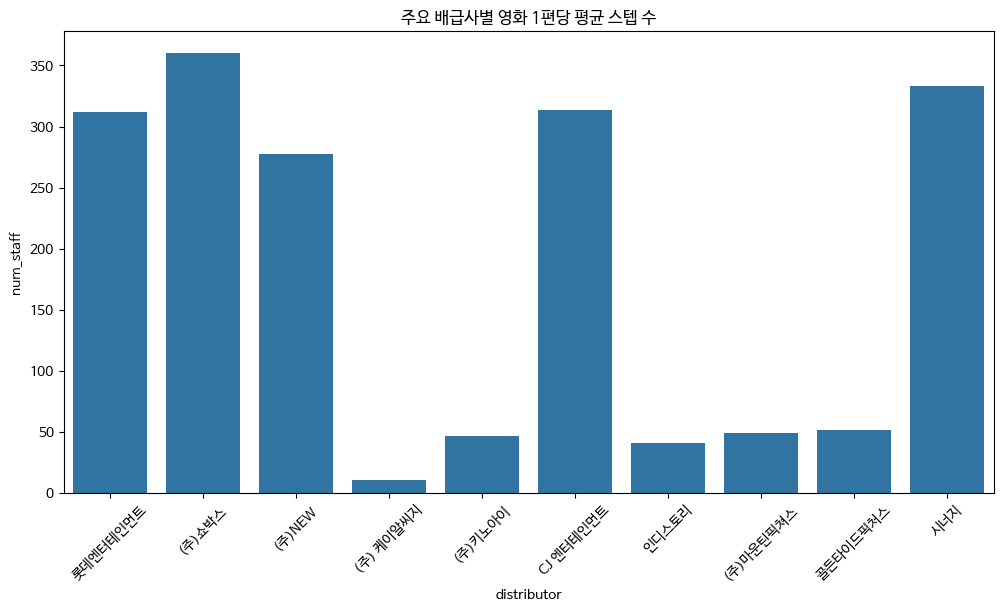

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(data=train_top10, x='distributor', y='num_staff', errorbar=None)
plt.title('주요 배급사별 영화 1편당 평균 스텝 수')
plt.xticks(rotation=45)
plt.show()

- 분석 결과 : CJ, 롯데, NEW, 쇼박스 같은 대형 배급사들이 영화 한 편에 투입하는 평균 스텝 수가 중소 배급사에 비해 압도적으로 많다.
- 배급사들의 제작 규모를 확인해 본 결과, 대형 배급사일수록 인적 자본을 많이 투입한다는 것을 알 수 있고 배급사의 자본이 스텝수로 이어진다는 사실까지 확인할 수 있다.



(2) 스텝 수 구간별 평균 관객수

"스텝이 많을 수록 관객수가 많을까?"

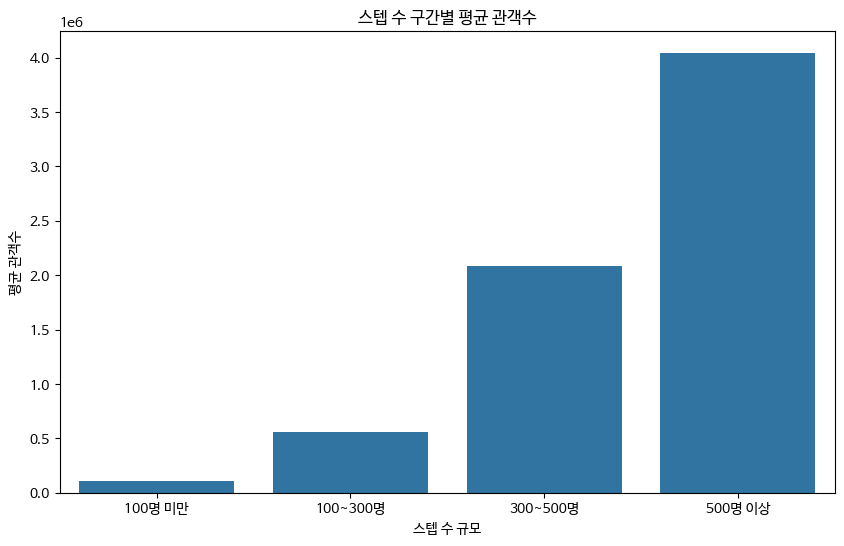

In [17]:
def staff_band(staff):
    if staff < 100: return '100명 미만'
    elif staff < 300: return '100~300명'
    elif staff < 500: return '300~500명'
    else: return '500명 이상'

train['스텝수_구간'] = train['num_staff'].apply(staff_band)

order = ['100명 미만', '100~300명', '300~500명', '500명 이상']

plt.figure(figsize=(10, 6))
sns.barplot(data=train, x='스텝수_구간', y='box_off_num', order=order, errorbar=None)

plt.title('스텝 수 구간별 평균 관객수')
plt.xlabel('스텝 수 규모')
plt.ylabel('평균 관객수')
plt.show()

- 분석 결과 : 스텝 수를 구간 별로 나누어 평균 관객 수를 확인했을 때, 스텝 수가 많아질수록 관객 수도 계단식으로 상승하는 '우상향' 모습이 나타난다.
- 결론적으로 개별 영화마다 차이는 있겠지만 전체적인 흐름을 보면 스텝 수가 평균 관객수에 정비례함을 알 수 있다. 이는 많은 인력이 투입될수록 영화의 완성도가 높아지거나 거대한 자본이 들어간 만큼 더 적극적인 마케팅이 이루어져 흥행 확률을 높인다는 것을 의미한다.

(3) 배급사 수준별 관객수 분포

"대형 배급사 (상위 4개)와 기타 배급사의 흥행 규모에는 차이가 있을까?"

- 이상치 발견 및 제거 : 초기 분석 시 개봉 영화 수 기준 상위권에 있던 '마운틴픽쳐스'를 발견 -> 해당 배급사는 개봉 영화 수는 많지만 저예산/다큐멘터리 위주로 '스텝 수와 흥행의 상관관계' 분석에 있어 전체적인 경향을 왜곡하므로 분석 대상에서 제외함
- 데이터 재그룹화 : 마운틴픽쳐스 제외 후 실제 영화 제작에서 영향력이 높은 상위 4개사를 추출하여 '대형 배급사'로 묶고 나머지를 '기타'로 분류함

In [6]:
# 1. 마운틴픽쳐스를 이상치로 처리한 후 제거
train_clean = train[train['distributor'] != '(주)마운틴픽쳐스'].copy()

# 2. 영화 제작 수 상위 4개 배급사
top4_list = train_clean['distributor'].value_counts().head(4).index

# 3. 나머지 배급사는 '기타'로 처리
train_clean['배급사_분류'] = train_clean['distributor'].apply(lambda x: x if x in top4_list else '기타')

print("--- 마운틴픽쳐스 제외 후 추출된 상위 4개사 ---")
print(list(top4_list))
print("\n--- 최종 그룹별 영화 개수 ---")
print(train_clean['배급사_분류'].value_counts())

--- 마운틴픽쳐스 제외 후 추출된 상위 4개사 ---
['CJ 엔터테인먼트', '롯데엔터테인먼트', '(주)NEW', '(주)쇼박스']

--- 최종 그룹별 영화 개수 ---
배급사_분류
기타           409
CJ 엔터테인먼트     54
롯데엔터테인먼트      52
(주)NEW        30
(주)쇼박스        26
Name: count, dtype: int64


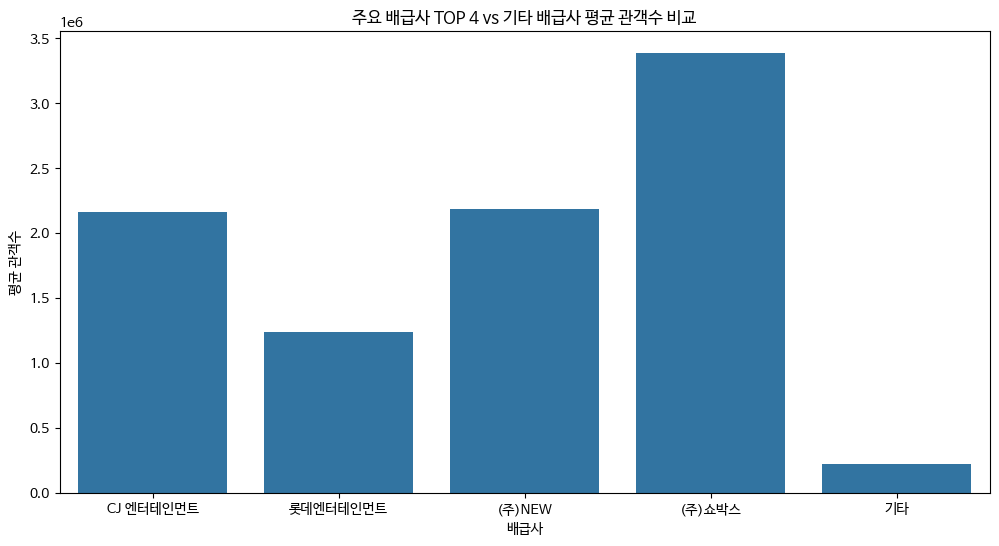

In [19]:
plt.figure(figsize=(12, 6))

sns.barplot(data=train_clean, x='배급사_분류', y='box_off_num', errorbar=None, order=list(top4_list) + ['기타'])

plt.title('주요 배급사 TOP 4 vs 기타 배급사 평균 관객수 비교')
plt.xlabel('배급사')
plt.ylabel('평균 관객수')
plt.show()

- 분석 결과 : 대형 배급사들이 기타 배급사 그룹을 몇 배 이상 앞지르는 것을 알 수 있다.
- 결론적으로 '대형 자본 -> 많은 스텝 투입 -> 높은 관객 수' 라는 흥행 공식이 데이터로 입증된 셈이다. 영화 산업에서 배급사의 규모는 단순히 이름값이 아니라 제작에 투입되는 자본의 양을 결정하고 이것이 결국 최종 흥행 성적을 가르는 결정적인 차이를 만든다.